In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load all CSV files
orders      = pd.read_csv("orders.csv")
deliveries  = pd.read_csv("deliveries.csv")
customers   = pd.read_csv("customers.csv")
drivers     = pd.read_csv("drivers.csv")
vehicles    = pd.read_csv("vehicles.csv")
hubs        = pd.read_csv("hubs.csv")
complaints  = pd.read_csv("complaints.csv")
incidents   = pd.read_csv("incidents.csv")
app_events  = pd.read_csv("app_events.csv")

Standardising Incosistent Zone Names

In [ ]:
zone_map = {
    'north':'North','NORTH':'North','North':'North',
    'south':'South','SOUTH':'South','South':'South',
    'east':'East','EAST':'East','East':'East',
    'west':'West','WEST':'West','West':'West',
    'Ctr':'Central','ctr':'Central','Central':'Central','CENTRAL':'Central',
    'Airport':'Airport','AIRPORT':'Airport',
    'RiverSide':'Riverside','Riverside':'Riverside','RIVERSIDE':'Riverside'
}

for df in [orders, customers, drivers, hubs, vehicles, app_events]:
    for col in df.columns:
        if 'zone' in col.lower():
            df[col] = df[col].map(zone_map).fillna(df[col])

Creating a unified Master Table

In [ ]:
# Merged orders with deliveries
master = orders.merge(deliveries, on='order_id', how='left')

# Merged with drivers, vehicles, hubs (select key columns)
master = master.merge(
    drivers[['driver_id','driver_rating','years_experience','training_score']],
    on='driver_id', how='left'
)
master = master.merge(
    vehicles[['vehicle_id','vehicle_type','battery_health_pct']],
    on='vehicle_id', how='left'
)
master = master.merge(
    hubs[['hub_id','hub_name','hub_type','capacity_score']],
    on='hub_id', how='left'
)

print(f"Master table shape: {master.shape}")
master.head()

Master table shape: (1250, 31)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,customer_rating_post_delivery,fuel_or_charge_cost,driver_rating,years_experience,training_score,vehicle_type,battery_health_pct,hub_name,hub_type,capacity_score
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,4.29,15.82,4.70,7.0,64.6,Hybrid,93.8,North Exchange,Dispatch,82.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,3.70,13.16,3.67,3.0,88.2,CargoVan,60.1,South Link,Dispatch,78.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,5.00,13.41,4.61,11.0,69.2,Diesel,68.6,South Link,Dispatch,78.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,4.38,13.53,4.32,3.0,80.1,Hybrid,NaN,East Dock,Warehouse,74.0


Handling Missing Values

In [ ]:
num_cols = ['route_distance_km','manual_route_override_count',
            'customer_rating_post_delivery','years_experience',
            'training_score','battery_health_pct','promised_window_hours']
master[num_cols] = master[num_cols].fillna(master[num_cols].median())

# Drop rows without a delivery outcome
master = master.dropna(subset=['delivery_status'])
print(f"Rows after cleaning: {len(master)}")

Rows after cleaning: 950


Failure Rate by Dropoff zone

/tmp/ipykernel_23158/2390495905.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=zone_stats.index, y='failure_pct', data=zone_stats, palette='Reds_r')


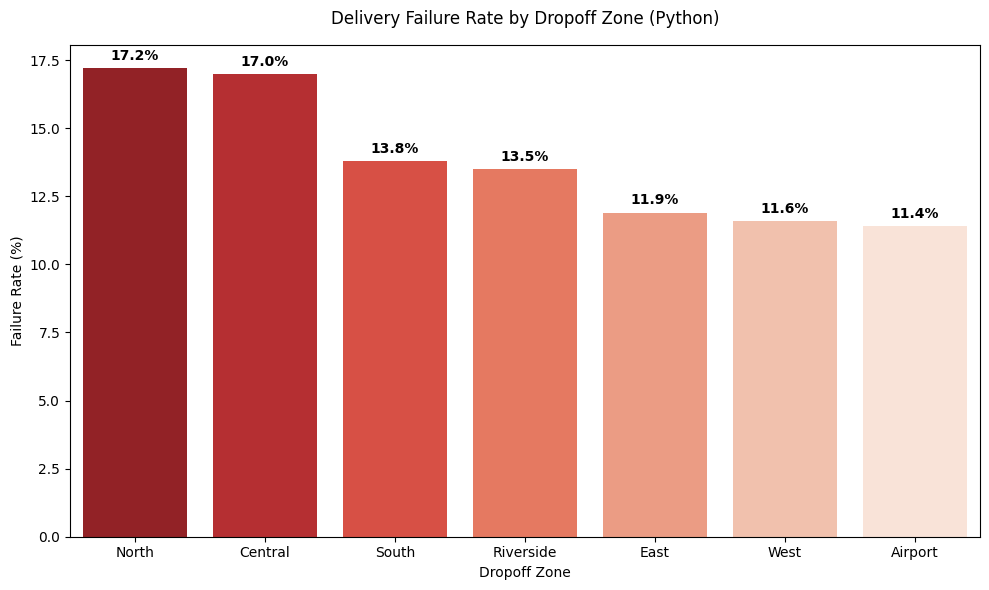

In [ ]:
zone_stats = master.groupby('dropoff_zone').agg(
    total_orders = ('order_id','count'),
    failures = ('delivery_status', lambda x: (x == 'Failed').sum())
)
zone_stats['failure_pct'] = (zone_stats['failures'] / zone_stats['total_orders'] * 100).round(1)
zone_stats = zone_stats.sort_values('failure_pct', ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=zone_stats.index, y='failure_pct', data=zone_stats, palette='Reds_r')
plt.title('Delivery Failure Rate by Dropoff Zone (Python)', pad=15)
plt.xlabel('Dropoff Zone')
plt.ylabel('Failure Rate (%)')
for i, v in enumerate(zone_stats['failure_pct']):
    ax.text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Correlation Heatmap of Performance Factors

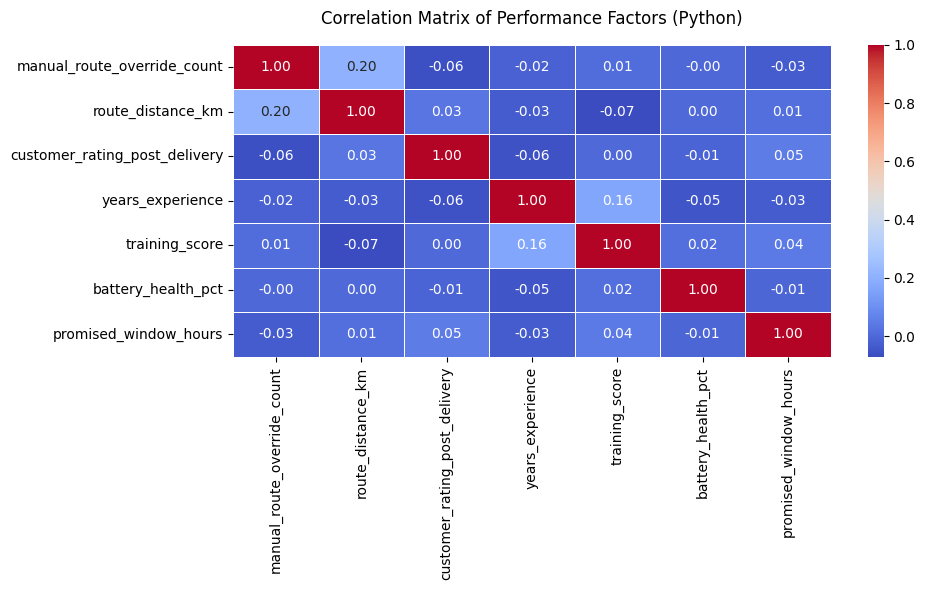

In [ ]:
plt.figure(figsize=(10,6))
corr_matrix = master[['manual_route_override_count','route_distance_km',
                     'customer_rating_post_delivery','years_experience',
                     'training_score','battery_health_pct','promised_window_hours']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Performance Factors (Python)', pad=15)
plt.tight_layout()
plt.show()

Delivery Outcome Distribution in North and Central

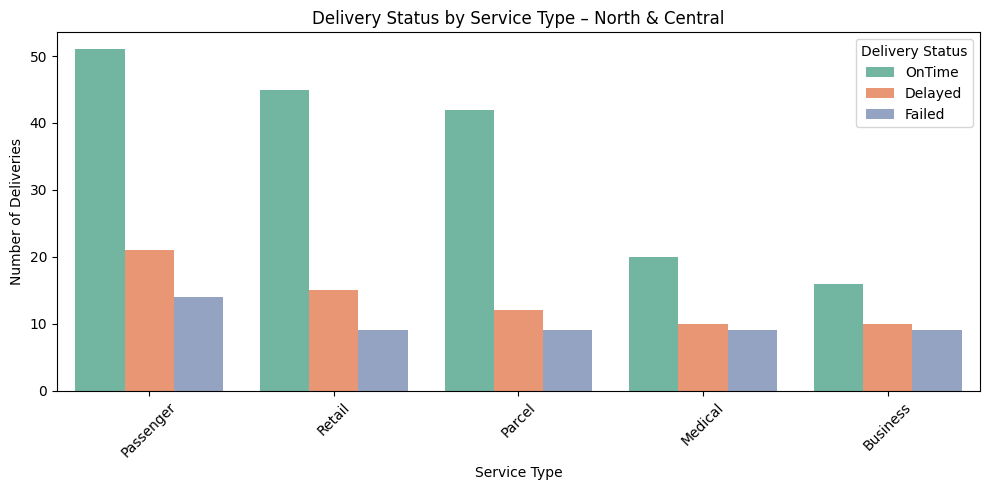

In [ ]:
problem_zones = master[master['dropoff_zone'].isin(['North','Central'])]
plt.figure(figsize=(10,5))
sns.countplot(data=problem_zones, x='service_type', hue='delivery_status',
              order=problem_zones['service_type'].value_counts().index,
              palette='Set2')
plt.title('Delivery Status by Service Type – North & Central')
plt.xlabel('Service Type')
plt.ylabel('Number of Deliveries')
plt.xticks(rotation=45)
plt.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

Predictive Modelling: Logistic Regression for Delivery Failure

In [ ]:
master['is_failed'] = (master['delivery_status'] == 'Failed').astype(int)

feature_cols = ['manual_route_override_count','route_distance_km',
                'promised_window_hours','driver_rating',
                'battery_health_pct','years_experience','training_score']
X = master[feature_cols]
y = master['is_failed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Not Failed','Failed']))

Confusion Matrix:
 [[245   0]
 [ 40   0]]

Classification Report:
               precision    recall  f1-score   support

  Not Failed       0.86      1.00      0.92       245
      Failed       0.00      0.00      0.00        40

    accuracy                           0.86       285
   macro avg       0.43      0.50      0.46       285
weighted avg       0.74      0.86      0.79       285



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Feature Importance from the Model

/tmp/ipykernel_23158/3385554947.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeff_df, x='Coefficient', y='Feature', palette='coolwarm')


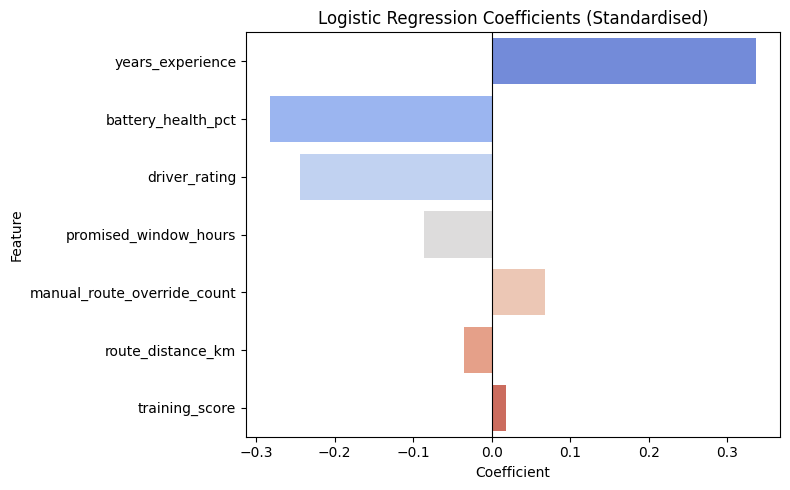

                       Feature  Coefficient
5             years_experience     0.336235
4           battery_health_pct    -0.281926
3                driver_rating    -0.243822
2        promised_window_hours    -0.086338
0  manual_route_override_count     0.068147
1            route_distance_km    -0.034627
6               training_score     0.018295


In [ ]:
coeff_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=coeff_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Logistic Regression Coefficients (Standardised)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(coeff_df)